### Softmax regression is used for multinomial logistic regression

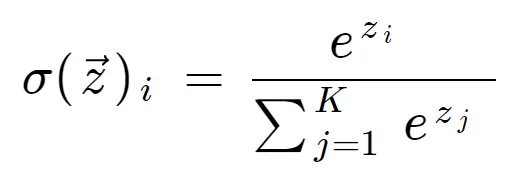

### The general intuition of this is that

| CGPA | IQ | 0 | 1 | 2 |
|------|----|---|---|---|
| 9.2  | 80 | 1 | 0 | 0 |
| 8.5  | 95 | 0 | 1 | 0 |
| 7.8  | 75 | 0 | 0 | 1 |

- First we will do the one_Hot_Encoding of y
- After that we will make sepeate dataset for each binary classification model
- Now we will train 3 models
- and we will get
- $w_0^0,w_1^0,w_2^0$
-  $w_0^1,w_1^1,w_2^1$
- $w_0^2,w_1^2,w_2^2$


For each class, we calculate a separate linear score:

$$
z_1 = 7w_1^{(1)} + 70w_2^{(1)} + w_0^{(1)}
$$

$$
z_2 = 7w_1^{(2)} + 70w_2^{(2)} + w_0^{(2)}
$$

$$
z_3 = 7w_1^{(3)} + 70w_2^{(3)} + w_0^{(3)}
$$

Now apply the **Softmax function** to each score.

For Class 1:

$$
\sigma(\vec{z})_1
=
\frac{e^{z_1}}
{e^{z_1} + e^{z_2} + e^{z_3}}
=
0.40
$$

For Class 2:

$$
\sigma(\vec{z})_2
=
\frac{e^{z_2}}
{e^{z_1} + e^{z_2} + e^{z_3}}
=
0.35
$$

For Class 3:

$$
\sigma(\vec{z})_3
=
\frac{e^{z_3}}
{e^{z_1} + e^{z_2} + e^{z_3}}
=
0.25
$$

Therefore, the final probability distribution is:

$$
P(y \mid x)
=
\begin{bmatrix}
0.40 & 0.35 & 0.25
\end{bmatrix}
$$

Since the highest probability is:

$$
\max(0.40, 0.35, 0.25) = 0.40
$$

the predicted class is:

$$
\boxed{\hat{y} = 1}
$$

## This is not how this works in the Sklearn


## The Loss Function in case of  Logistic Regression is
## $/boxed{}$

# Softmax Regression — Real Mathematical Implementation from Scratch

> Goal: derive and implement **multiclass Softmax Regression** using the same loss-function route commonly used in the linked lecture:  
> **probability → likelihood → log-likelihood → negative log-likelihood / cross-entropy → gradient descent**.
>
> This is not `sklearn.LogisticRegression`. We build the model with NumPy.

---

## 1. Problem Setup

Suppose:

- Number of training samples = \(m\)
- Number of input features = \(n\)
- Number of classes = \(K\)

Input matrix:

$$
X \in \mathbb{R}^{m \times n}
$$

Weight matrix:

$$
W \in \mathbb{R}^{n \times K}
$$

Bias vector:

$$
b \in \mathbb{R}^{1 \times K}
$$

For one sample \(x^{(i)}\), the model creates one score (logit) for every class:

$$
z_k^{(i)} = x^{(i)T}w_k + b_k
$$

For all classes:

$$
z^{(i)} =
\begin{bmatrix}
z_1^{(i)} &
z_2^{(i)} &
\cdots &
z_K^{(i)}
\end{bmatrix}
$$

For the complete dataset:

$$
Z = XW + b
$$

Shape:

$$
(m \times n)(n \times K) + (1 \times K)
=
(m \times K)
$$

---

## 2. Why We Cannot Directly Use the Logits

Assume a sample produces:

$$
z =
\begin{bmatrix}
2.0 & 1.0 & 0.1
\end{bmatrix}
$$

These are only raw scores.

They are **not probabilities** because:

- values may be negative
- values may be greater than 1
- their sum is not necessarily 1

We convert them into probabilities using **Softmax**.

---

## 3. Softmax Function

For class \(k\):

$$
P(y=k \mid x)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K} e^{z_j}}
$$

Therefore:

$$
\hat{y}_k
=
\frac{e^{z_k}}
{e^{z_1}+e^{z_2}+\cdots+e^{z_K}}
$$

For three classes:

$$
\hat{y}_1 =
\frac{e^{z_1}}
{e^{z_1}+e^{z_2}+e^{z_3}}
$$

$$
\hat{y}_2 =
\frac{e^{z_2}}
{e^{z_1}+e^{z_2}+e^{z_3}}
$$

$$
\hat{y}_3 =
\frac{e^{z_3}}
{e^{z_1}+e^{z_2}+e^{z_3}}
$$

and:

$$
\hat{y}_1+\hat{y}_2+\hat{y}_3=1
$$

### Numerically stable Softmax

Directly computing \(e^z\) can overflow.

So we use:

$$
z_{\text{stable}}
=
z-\max(z)
$$

Then:

$$
\text{softmax}(z)_k
=
\frac{e^{z_k-\max(z)}}
{\sum_j e^{z_j-\max(z)}}
$$

This does **not** change the final probabilities.

```python
def softmax(Z):
    Z_stable = Z - np.max(Z, axis=1, keepdims=True)

    exp_Z = np.exp(Z_stable)

    probabilities = exp_Z / np.sum(
        exp_Z,
        axis=1,
        keepdims=True
    )

    return probabilities
```

---

# 4. Deriving the Loss Function from Probability

This is the important part.

Suppose there are \(K\) classes.

For one training sample \(i\), let:

$$
y^{(i)}
$$

be the actual class.

The model predicts:

$$
P(y=k \mid x^{(i)})
=
\hat{y}_k^{(i)}
$$

---

## 4.1 One-Hot Representation

Suppose there are three classes:

- Class 0
- Class 1
- Class 2

If the actual class is Class 1:

$$
y =
\begin{bmatrix}
0 & 1 & 0
\end{bmatrix}
$$

Suppose predicted probabilities are:

$$
\hat{y}
=
\begin{bmatrix}
0.1 & 0.7 & 0.2
\end{bmatrix}
$$

The probability assigned to the correct class is:

$$
0.7
$$

Using one-hot encoding, we can select the correct probability with:

$$
P(y \mid x)
=
\prod_{k=1}^{K}
\hat{y}_k^{y_k}
$$

Why?

Because if:

$$
y =
\begin{bmatrix}
0 & 1 & 0
\end{bmatrix}
$$

then:

$$
P(y \mid x)
=
(0.1)^0(0.7)^1(0.2)^0
$$

Since:

$$
a^0=1
$$

we get:

$$
P(y \mid x)=0.7
$$

So the general expression is:

$$
P(y^{(i)} \mid x^{(i)})
=
\prod_{k=1}^{K}
\left(
\hat{y}_k^{(i)}
\right)^{y_k^{(i)}}
$$

---

## 4.2 Likelihood for the Complete Dataset

For \(m\) independent training examples:

$$
L(W,b)
=
\prod_{i=1}^{m}
P(y^{(i)} \mid x^{(i)})
$$

Substitute the one-hot expression:

$$
L(W,b)
=
\prod_{i=1}^{m}
\prod_{k=1}^{K}
\left(
\hat{y}_k^{(i)}
\right)^{y_k^{(i)}}
$$

Our objective is to find parameters \(W,b\) that maximize this likelihood:

$$
\max_{W,b} L(W,b)
$$

---

## 4.3 Take Log of the Likelihood

Products are inconvenient for differentiation and can become numerically tiny.

Take logarithm:

$$
\log L(W,b)
=
\log
\left[
\prod_{i=1}^{m}
\prod_{k=1}^{K}
\left(
\hat{y}_k^{(i)}
\right)^{y_k^{(i)}}
\right]
$$

Using:

$$
\log(ab)=\log a+\log b
$$

we get:

$$
\log L(W,b)
=
\sum_{i=1}^{m}
\sum_{k=1}^{K}
\log
\left[
\left(
\hat{y}_k^{(i)}
\right)^{y_k^{(i)}}
\right]
$$

Using:

$$
\log(a^b)=b\log(a)
$$

we get:

$$
\log L(W,b)
=
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log
\left(
\hat{y}_k^{(i)}
\right)
$$

This is the **log-likelihood**.

---

## 4.4 Convert Maximization into Minimization

Gradient descent minimizes a cost function.

We currently want:

$$
\max_{W,b}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log
\left(
\hat{y}_k^{(i)}
\right)
$$

Multiply by \(-1\):

$$
\min_{W,b}
-
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log
\left(
\hat{y}_k^{(i)}
\right)
$$

Take the average over \(m\) samples:

$$
\boxed{
J(W,b)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log
\left(
\hat{y}_k^{(i)}
\right)
}
$$

This is the **Categorical Cross-Entropy Loss**.

It is also the **Negative Log-Likelihood** for the multiclass model.

---

# 5. Why Only the Correct Class Contributes to Loss

Suppose:

$$
y =
\begin{bmatrix}
0 & 1 & 0
\end{bmatrix}
$$

and:

$$
\hat{y}
=
\begin{bmatrix}
0.1 & 0.7 & 0.2
\end{bmatrix}
$$

Loss:

$$
L
=
-
\left[
0\log(0.1)
+
1\log(0.7)
+
0\log(0.2)
\right]
$$

Therefore:

$$
L=-\log(0.7)
$$

So for a single sample:

$$
\boxed{
L_i
=
-\log
\left(
P(\text{correct class}\mid x^{(i)})
\right)
}
$$

If the model gives high probability to the correct class, loss is small.

If the model gives low probability to the correct class, loss is large.

---

# 6. Substitute Softmax into the Loss

For one sample:

$$
L_i
=
-
\sum_{k=1}^{K}
y_k
\log(\hat{y}_k)
$$

Softmax gives:

$$
\hat{y}_k
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

Substitute:

$$
L_i
=
-
\sum_{k=1}^{K}
y_k
\log
\left(
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
\right)
$$

Using:

$$
\log\left(\frac{a}{b}\right)
=
\log(a)-\log(b)
$$

we get:

$$
L_i
=
-
\sum_{k=1}^{K}
y_k
\left[
\log(e^{z_k})
-
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
\right]
$$

Since:

$$
\log(e^{z_k})=z_k
$$

therefore:

$$
L_i
=
-
\sum_{k=1}^{K}
y_k
\left[
z_k
-
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
\right]
$$

Expand:

$$
L_i
=
-
\sum_{k=1}^{K}y_kz_k
+
\sum_{k=1}^{K}
y_k
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
$$

For one-hot encoded \(y\):

$$
\sum_{k=1}^{K}y_k=1
$$

Hence:

$$
\boxed{
L_i
=
-
\sum_{k=1}^{K}y_kz_k
+
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
}
$$

Equivalent compact form:

$$
\boxed{
L_i
=
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
-
y^Tz
}
$$

---

# 7. Derivative of Loss with Respect to Logits

We now derive the key result:

$$
\boxed{
\frac{\partial L}{\partial z_k}
=
\hat{y}_k-y_k
}
$$

Start from:

$$
L
=
-
\sum_{j=1}^{K}y_jz_j
+
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
$$

Differentiate with respect to \(z_k\).

---

## 7.1 Derivative of First Term

$$
\frac{\partial}{\partial z_k}
\left(
-
\sum_{j=1}^{K}y_jz_j
\right)
=
-y_k
$$

---

## 7.2 Derivative of Second Term

$$
\frac{\partial}{\partial z_k}
\log
\left(
\sum_{j=1}^{K}e^{z_j}
\right)
$$

Using chain rule:

$$
=
\frac{1}
{\sum_{j=1}^{K}e^{z_j}}
\cdot
e^{z_k}
$$

Therefore:

$$
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

But this is exactly Softmax:

$$
=
\hat{y}_k
$$

---

## 7.3 Final Derivative

Combine both terms:

$$
\frac{\partial L}{\partial z_k}
=
-y_k+\hat{y}_k
$$

Therefore:

$$
\boxed{
\frac{\partial L}{\partial z_k}
=
\hat{y}_k-y_k
}
$$

For all classes:

$$
\boxed{
\frac{\partial L}{\partial z}
=
\hat{y}-y
}
$$

For all training samples:

$$
\boxed{
\frac{\partial J}{\partial Z}
=
\frac{1}{m}
(\hat{Y}-Y)
}
$$

This is the central gradient used by Softmax Regression.

---

# 8. Derivative with Respect to Weights

We have:

$$
Z=XW+b
$$

and:

$$
\frac{\partial J}{\partial Z}
=
\frac{1}{m}(\hat{Y}-Y)
$$

By chain rule:

$$
\frac{\partial J}{\partial W}
=
X^T
\frac{\partial J}{\partial Z}
$$

Therefore:

$$
\boxed{
\frac{\partial J}{\partial W}
=
\frac{1}{m}
X^T(\hat{Y}-Y)
}
$$

Shape check:

$$
X^T:
(n \times m)
$$

$$
(\hat{Y}-Y):
(m \times K)
$$

Therefore:

$$
dW:
(n \times K)
$$

which matches the shape of \(W\).

---

# 9. Derivative with Respect to Bias

Because:

$$
Z=XW+b
$$

the bias gradient is:

$$
\boxed{
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\hat{y}^{(i)}-y^{(i)}
\right)
}
$$

In NumPy:

```python
db = np.mean(Y_hat - Y_one_hot, axis=0, keepdims=True)
```

---

# 10. Gradient Descent Update Rule

For weights:

$$
\boxed{
W
:=
W-\alpha
\frac{\partial J}{\partial W}
}
$$

For bias:

$$
\boxed{
b
:=
b-\alpha
\frac{\partial J}{\partial b}
}
$$

where:

$$
\alpha = \text{learning rate}
$$

Substituting gradients:

$$
W
:=
W
-
\alpha
\left[
\frac{1}{m}
X^T(\hat{Y}-Y)
\right]
$$

and:

$$
b
:=
b
-
\alpha
\left[
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})
\right]
$$

---

# 11. Complete NumPy Implementation from Scratch

```python
import numpy as np


class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.W = None
        self.b = None

        self.classes_ = None
        self.loss_history = []


    # -------------------------------------------------
    # 1. Numerically stable softmax
    # -------------------------------------------------
    def softmax(self, Z):

        # subtract row-wise maximum for numerical stability
        Z_stable = Z - np.max(
            Z,
            axis=1,
            keepdims=True
        )

        exp_Z = np.exp(Z_stable)

        probabilities = exp_Z / np.sum(
            exp_Z,
            axis=1,
            keepdims=True
        )

        return probabilities


    # -------------------------------------------------
    # 2. One-hot encoding
    # -------------------------------------------------
    def one_hot_encode(self, y):

        m = y.shape[0]
        K = len(self.classes_)

        Y_one_hot = np.zeros((m, K))

        # map original labels to 0, 1, ..., K-1
        class_to_index = {
            label: index
            for index, label in enumerate(self.classes_)
        }

        for i in range(m):
            class_index = class_to_index[y[i]]
            Y_one_hot[i, class_index] = 1

        return Y_one_hot


    # -------------------------------------------------
    # 3. Cross-entropy / negative log-likelihood
    # -------------------------------------------------
    def compute_loss(self, Y_one_hot, Y_hat):

        m = Y_one_hot.shape[0]

        # avoid log(0)
        epsilon = 1e-15

        Y_hat_clipped = np.clip(
            Y_hat,
            epsilon,
            1 - epsilon
        )

        loss = -(
            1 / m
        ) * np.sum(
            Y_one_hot * np.log(Y_hat_clipped)
        )

        return loss


    # -------------------------------------------------
    # 4. Train using batch gradient descent
    # -------------------------------------------------
    def fit(self, X, y):

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        m, n = X.shape

        # unique class labels
        self.classes_ = np.unique(y)

        K = len(self.classes_)

        # one-hot actual outputs
        Y_one_hot = self.one_hot_encode(y)

        # initialize parameters
        self.W = np.zeros((n, K))
        self.b = np.zeros((1, K))

        self.loss_history = []


        for epoch in range(self.epochs):

            # ==========================================
            # FORWARD PASS
            # ==========================================

            # Z = XW + b
            Z = X @ self.W + self.b

            # probabilities
            Y_hat = self.softmax(Z)


            # ==========================================
            # LOSS
            # J = -(1/m) sum_i sum_k y_ik log(yhat_ik)
            # ==========================================

            loss = self.compute_loss(
                Y_one_hot,
                Y_hat
            )

            self.loss_history.append(loss)


            # ==========================================
            # BACKWARD PASS
            # ==========================================

            # dJ/dZ
            #
            # mathematically:
            # dZ = (1/m)(Y_hat - Y)
            #
            error = Y_hat - Y_one_hot


            # dJ/dW
            #
            # dW = (1/m) X^T (Y_hat - Y)
            #
            dW = (1 / m) * (
                X.T @ error
            )


            # dJ/db
            #
            # db = (1/m) sum(Y_hat - Y)
            #
            db = (1 / m) * np.sum(
                error,
                axis=0,
                keepdims=True
            )


            # ==========================================
            # GRADIENT DESCENT UPDATE
            # ==========================================

            self.W = (
                self.W
                -
                self.learning_rate * dW
            )

            self.b = (
                self.b
                -
                self.learning_rate * db
            )


            # print progress
            if epoch % 100 == 0:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Loss = {loss:.6f}"
                )

        return self


    # -------------------------------------------------
    # 5. Predict class probabilities
    # -------------------------------------------------
    def predict_proba(self, X):

        X = np.asarray(X, dtype=np.float64)

        Z = X @ self.W + self.b

        probabilities = self.softmax(Z)

        return probabilities


    # -------------------------------------------------
    # 6. Predict actual class
    # -------------------------------------------------
    def predict(self, X):

        probabilities = self.predict_proba(X)

        # index of largest probability
        class_indices = np.argmax(
            probabilities,
            axis=1
        )

        # convert index back to original label
        predictions = self.classes_[class_indices]

        return predictions
```

---

# 12. Real Example on the Iris Dataset

```python
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# -----------------------------------------
# Load dataset
# -----------------------------------------
iris = load_iris()

X = iris.data
y = iris.target


# -----------------------------------------
# Train-test split
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -----------------------------------------
# Feature scaling
# -----------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------------------
# Create model
# -----------------------------------------
model = SoftmaxRegression(
    learning_rate=0.1,
    epochs=2000
)


# -----------------------------------------
# Train
# -----------------------------------------
model.fit(
    X_train,
    y_train
)


# -----------------------------------------
# Predictions
# -----------------------------------------
y_pred = model.predict(X_test)


# -----------------------------------------
# Accuracy
# -----------------------------------------
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)
```

---

# 13. Plot the Loss Curve

```python
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.plot(
    model.loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Softmax Regression Training Loss")

plt.grid()

plt.show()
```

The expected behavior is that the loss decreases as gradient descent updates \(W\) and \(b\).

---

# 14. Inspect Predicted Probabilities

```python
probabilities = model.predict_proba(
    X_test[:5]
)

print(probabilities)
```

Each row should sum approximately to 1:

```python
print(
    np.sum(
        probabilities,
        axis=1
    )
)
```

Example conceptual output:

```text
[[0.02 0.91 0.07]
 [0.95 0.04 0.01]
 [0.01 0.10 0.89]]
```

Predicted class:

```python
predictions = np.argmax(
    probabilities,
    axis=1
)

print(predictions)
```

---

# 15. Matrix Form of the Entire Algorithm

## Forward Pass

### Step 1: Logits

$$
\boxed{
Z=XW+b
}
$$

### Step 2: Softmax

$$
\boxed{
\hat{Y}_{ik}
=
\frac{e^{Z_{ik}}}
{\sum_{j=1}^{K}e^{Z_{ij}}}
}
$$

### Step 3: Cross-Entropy Loss

$$
\boxed{
J
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
Y_{ik}\log(\hat{Y}_{ik})
}
$$

---

## Backward Pass

### Step 4: Logit Error

$$
\boxed{
E=\hat{Y}-Y
}
$$

### Step 5: Weight Gradient

$$
\boxed{
dW
=
\frac{1}{m}X^TE
}
$$

### Step 6: Bias Gradient

$$
\boxed{
db
=
\frac{1}{m}
\sum_{i=1}^{m}E_i
}
$$

---

## Parameter Update

### Step 7: Update Weights

$$
\boxed{
W:=W-\alpha dW
}
$$

### Step 8: Update Bias

$$
\boxed{
b:=b-\alpha db
}
$$

---

# 16. The Complete Training Loop in Only a Few Lines

Once the mathematics is understood, the entire core algorithm is:

```python
for epoch in range(epochs):

    # forward
    Z = X @ W + b

    Y_hat = softmax(Z)

    # loss
    loss = -np.mean(
        np.sum(
            Y_one_hot * np.log(Y_hat + 1e-15),
            axis=1
        )
    )

    # gradients
    error = Y_hat - Y_one_hot

    dW = (1 / m) * X.T @ error

    db = (1 / m) * np.sum(
        error,
        axis=0,
        keepdims=True
    )

    # update
    W = W - learning_rate * dW

    b = b - learning_rate * db
```

That is the real vectorized implementation of Softmax Regression.

---

# 17. Important Connection with Binary Logistic Regression

Binary Logistic Regression uses:

$$
\hat{y}
=
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

and binary cross-entropy:

$$
J
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

Softmax Regression generalizes this idea to \(K\) classes:

$$
\hat{y}_k
=
\frac{e^{z_k}}
{\sum_j e^{z_j}}
$$

with categorical cross-entropy:

$$
J
=
-\frac{1}{m}
\sum_i
\sum_k
y_{ik}\log(\hat{y}_{ik})
$$

The key gradient becomes:

$$
\boxed{
dZ=\hat{Y}-Y
}
$$

and therefore:

$$
\boxed{
dW
=
\frac{1}{m}
X^T(\hat{Y}-Y)
}
$$

---

# 18. Final Algorithm Summary

Given:

$$
X \in \mathbb{R}^{m\times n}
$$

initialize:

$$
W \in \mathbb{R}^{n\times K}
$$

$$
b \in \mathbb{R}^{1\times K}
$$

Then repeatedly calculate:

$$
Z=XW+b
$$

$$
\hat{Y}=\text{softmax}(Z)
$$

$$
J
=
-\frac{1}{m}
\sum_i
\sum_k
Y_{ik}\log(\hat{Y}_{ik})
$$

$$
dW
=
\frac{1}{m}
X^T(\hat{Y}-Y)
$$

$$
db
=
\frac{1}{m}
\sum_i(\hat{Y}_i-Y_i)
$$

$$
W:=W-\alpha dW
$$

$$
b:=b-\alpha db
$$

Prediction:

$$
\boxed{
\hat{c}
=
\arg\max_k
P(y=k\mid x)
}
$$

---

## Final Core Result

The entire derivation collapses to the extremely important identity:

$$
\boxed{
\frac{\partial J}{\partial Z}
=
\frac{1}{m}
(\hat{Y}-Y)
}
$$

which produces:

$$
\boxed{
\frac{\partial J}{\partial W}
=
\frac{1}{m}
X^T(\hat{Y}-Y)
}
$$

This is the mathematical heart of Softmax Regression trained with categorical cross-entropy and batch gradient descent.


In [1]:
from sklearn.model_selection import train_test_split
import numpy  as np
import pandas as pd


In [2]:
df = pd.read_csv("/run/media/darshchouhan/New Volume/ML-Algorithm/Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df[['SepalLengthCm','PetalLengthCm','Species']]

In [5]:
df.head()

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,Iris-setosa
1,4.9,1.4,Iris-setosa
2,4.7,1.3,Iris-setosa
3,4.6,1.5,Iris-setosa
4,5.0,1.4,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder
lr= LabelEncoder()
df['Species']=lr.fit_transform(df['Species'])

In [8]:
df.head()

,SepalLengthCm,PetalLengthCm,Species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [9]:
from sklearn.model_selection import train_test_split

In [36]:
X  = df.drop('Species',axis=1)
y = df['Species']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)

In [14]:
from sklearn.linear_model import LogisticRegression

In [17]:
clf=LogisticRegression()
# in the newr version it automatically detects we dont need to pass the multi_class = 'multinomial

In [18]:
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
output  = clf.predict(X_test)


In [20]:
from sklearn.metrics import accuracy_score

In [21]:
print(accuracy_score(y_test,output))

0.9210526315789473


In [23]:
query = np.array([[3.4,2.7]])
clf.predict_proba(query)

/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[8.95570056e-01, 1.04202440e-01, 2.27503993e-04]])

In [24]:
clf.predict(query)

/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

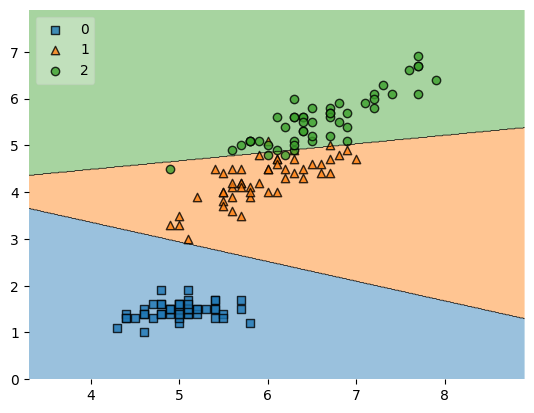

In [28]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf,legend=2)

# Polynimial Features in Logistic regression

In [29]:
# we can transfom the data to the polynomial features then we will apply logistic regression then 

In [33]:
from sklearn.preprocessing import  PolynomialFeatures
poly = PolynomialFeatures(degree=2)

In [39]:
X_tra = poly.fit_transform(X)

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X_tra,y)

In [41]:
clf2 = LogisticRegression()
clf2.fit(X_train,y_train)

/home/darshchouhan/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
res=clf2.predict(X_test)

In [43]:
print(accuracy_score(y_test,res))

0.9473684210526315


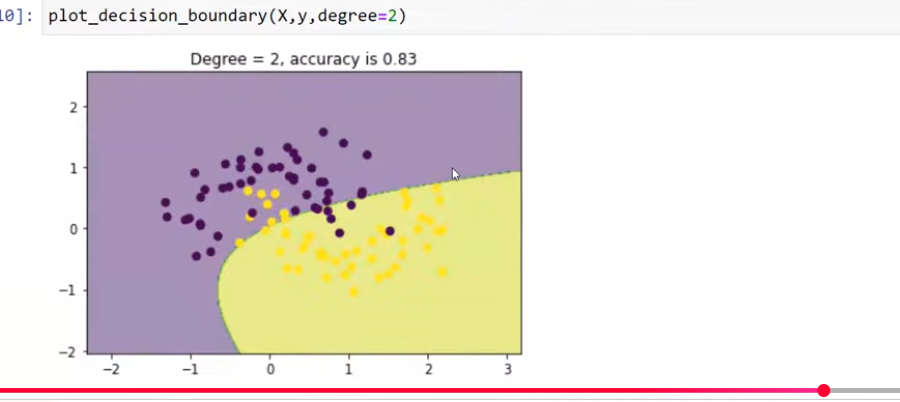